# GalaxyMNIST S4 Model Training, Evaluation, and Weight Export (PyTorch Version)

## About GalaxyMNIST

GalaxyMNIST is a dataset of galaxy morphology images designed as an astronomy-specific alternative to traditional benchmark datasets like MNIST. Created by Mike Walmsley and colleagues, it contains 10,000 galaxies from the Galaxy Zoo project, each labeled as one of four morphological types:

- **Smooth Round**: Elliptical galaxies with smooth, featureless light distributions
- **Smooth Cigar**: Elongated elliptical galaxies viewed edge-on
- **Edge-on Disk**: Spiral galaxies viewed edge-on, showing a thin disk structure
- **Unbarred Spiral**: Face-on spiral galaxies with visible spiral arm patterns

Each image is 64×64 pixels with 3 color channels (RGB), derived from SDSS imaging data. The dataset presents a more challenging and scientifically relevant classification task compared to handwritten digits, with real-world astronomical noise, varying brightness scales, and subtle morphological differences.

**References:**
- Walmsley, M., et al. (2022). "Galaxy Zoo DECaLS: Detailed visual morphology measurements from volunteers and deep learning for 314,000 galaxies." *Monthly Notices of the Royal Astronomical Society*, 509(3), 3966-3988.
- GalaxyMNIST Repository: https://github.com/mwalmsley/galaxy_mnist

---

**This notebook** demonstrates training a Structured State Space (S4) model for galaxy morphology classification. We convert RGB images to grayscale, flatten them using a Hilbert curve to preserve spatial locality, and process them as 1D sequences of 4,096 pixels. The S4 architecture's ability to capture long-range dependencies makes it well-suited for this task, achieving competitive performance without traditional convolutional layers.

## Preliminary Setup

Note: Python version 3.11.7 is used in this notebook.

In [1]:
# 1. Clone the ENTIRE repository
!git clone https://github.com/ahsan-c0ding/S4-Enhancement-Exploration.git

# 2. Move into the cloned repository folder
%cd S4-Enhancement-Exploration

# 3. Switch to the correct branch
!git checkout python

# 4. Install dependencies (just in case they aren't installed yet in this session)
!pip install transformers torchinfo tqdm scikit-learn 'accelerate>=1.1.0'

print("Repository cloned and working directory set!")

Cloning into 'S4-Enhancement-Exploration'...
remote: Enumerating objects: 827, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 827 (delta 40), reused 57 (delta 31), pack-reused 748 (from 1)
Receiving objects: 100% (827/827), 55.81 MiB | 12.90 MiB/s, done.
Resolving deltas: 100% (373/373), done.
/content/S4-Enhancement-Exploration
Branch 'python' set up to track remote branch 'python' from 'origin'.
Switched to a new branch 'python'
Repository cloned and working directory set!


In [2]:
# Check if GPU is available
!nvidia-smi

Fri Jul  3 15:17:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# If you have a GPU, prefer installing the CUDA version of PyTorch
# Refer to https://pytorch.org/get-started/locally/ for specific instructions.
# For example for CUDA 13.0, you can use the following command:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

# For CPU-only installation, you can use the following command:
# %pip install torch torchvision

# Other dependencies
%pip install numpy matplotlib scikit-learn h5py tqdm seaborn torchinfo einops

Looking in indexes: https://download.pytorch.org/whl/cu130


In [4]:
# Install GalaxyMNIST from source
# The specific commit used is: https://github.com/mwalmsley/galaxy_mnist/tree/c1fe9853a00bc34b2ff082585c6bb1654d34d239
%pip install git+https://github.com/mwalmsley/galaxy_mnist.git@c1fe9853a00bc34b2ff082585c6bb1654d34d239

  Cloning https://github.com/mwalmsley/galaxy_mnist.git (to revision c1fe9853a00bc34b2ff082585c6bb1654d34d239) to /tmp/pip-req-build-4m83pkhh
  Running command git clone --filter=blob:none --quiet https://github.com/mwalmsley/galaxy_mnist.git /tmp/pip-req-build-4m83pkhh
  Running command git rev-parse -q --verify 'sha^c1fe9853a00bc34b2ff082585c6bb1654d34d239'
  Running command git fetch -q https://github.com/mwalmsley/galaxy_mnist.git c1fe9853a00bc34b2ff082585c6bb1654d34d239
  Running command git checkout -q c1fe9853a00bc34b2ff082585c6bb1654d34d239
  Resolved https://github.com/mwalmsley/galaxy_mnist.git to commit c1fe9853a00bc34b2ff082585c6bb1654d34d239
  Preparing metadata (setup.py) ... done
  Created wheel for galaxyMNIST: filename=galaxyMNIST-0.1.0-py3-none-any.whl size=16425 sha256=a6e597cb4886eb6d3a88c5e8746d03566d77fa3ce476ed6ded3ced429e4df0f7
  Stored in directory: /root/.cache/pip/wheels/69/23/db/ce0f5fa5a7c0502eea2b1b8d29acf2622452835b179f8cc165
Successfully built galaxyMNIS

## 1. Imports and Configurations

In [5]:
import os
import sys

# 1. Change the working directory to the cloned repository
%cd S4-Enhancement-Exploration

# 2. Add the current directory to the Python path so it can find the 'model' folder
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

print(f"Working directory set to: {current_dir}")
print("Python path updated. You can now run your imports!")

[Errno 2] No such file or directory: 'S4-Enhancement-Exploration'
/content/S4-Enhancement-Exploration
Working directory set to: /content/S4-Enhancement-Exploration
Python path updated. You can now run your imports!


In [6]:
%pip install coloredlogs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.9 MB/s eta 0:00:00


In [7]:
# Standard library
import csv
import random

# Numerical / plotting
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tqdm import tqdm   #before it was from tqdm.notebook import tqd

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

# Classifier
from model import GalaxyClassifierS4D
from model.functions import export_model_parameters, load_data

from utils import set_pbar_style

In [8]:
set_pbar_style(bar_fill_color="#FFFFFF", text_color="#FFFFFF") # Make progress bars look good in notebooks
DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # Set device

CLASS_NAMES =  ["Smooth Round", "Smooth Cigar", "Edge-on Disk", "Unbarred Spiral"] # Class names for GalaxyMNIST

# Whether to use colored images
COLORED = False  # Start with grayscale

# Set RNG seeds for reproducibility
# Use your ERP id...
RNG_SEED = 30485 # TODO: Replace with your ERP id for actual experiments

# Set seeds
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RNG_SEED)

print(f"Using RNG seed: {RNG_SEED}")
print(f"Using device: {DEVICE}")

Using RNG seed: 30485
Using device: cuda


In [9]:
# Visualization inside the jupyter
%matplotlib inline

# Load the "autoreload" extension so that code can change
%load_ext autoreload

# ----------
# Plot
# ----------
# graph style
sns.set_style("darkgrid")
plt.style.use('fivethirtyeight')

# ----------
# Seaborn rcParams
# ----------
rc={'savefig.dpi': 500,
    'figure.autolayout': True,
    'figure.figsize': [17, 12],
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'font.size': 10,
    'lines.linewidth': 1.0,
    'lines.markersize': 8,
    'legend.fontsize': 15,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10}

sns.set_theme(context='notebook',  # notebook
        style='darkgrid',
        palette='deep',
        color_codes=True,
        rc=rc)

ModuleNotFoundError: No module named 'imp'

## 2. Load and Preprocess the GalaxyMNIST Dataset

We load the GalaxyMNIST dataset and preprocess it by converting RGB images to grayscale (averaging across channels) and normalizing pixel values to the [0, 1] range. The labels are converted to one-hot encoding for compatibility with the cross-entropy loss function.

In [10]:
X, y_onehot, y = load_data(root="./data", download=True, train=True, colored=COLORED)
NUM_CLASSES = y_onehot.shape[1]

100%|██████████| 68.7M/68.7M [00:06<00:00, 10.0MB/s]
100%|██████████| 17.3M/17.3M [00:02<00:00, 7.45MB/s]


Original Dataset Size: 8000 samples


In [11]:
# Verify the new dataset size
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y_onehot shape: {y_onehot.shape}")
print(f"Number of classes: {NUM_CLASSES}")

X shape: torch.Size([8000, 1, 64, 64])
y shape: torch.Size([8000])
y_onehot shape: torch.Size([8000, 4])
Number of classes: 4


### 2.2 Prepare the Test and Train Datasets

We split the dataset into training (80%) and validation (20%) sets using stratified sampling to maintain class balance. PyTorch DataLoaders are created with a batch size of 64 for efficient mini-batch training.

In [12]:
BATCH_SIZE = 64

# Split into train/validation sets
x_train, x_val, y_train_onehot, y_val_onehot = train_test_split(X, y_onehot, test_size=0.2, random_state=RNG_SEED, stratify=y)

# Create TensorDatasets
train_ds = TensorDataset(x_train, y_train_onehot)
val_ds = TensorDataset(x_val, y_val_onehot)

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

### 2.3 Save Sample Images for Later Use in C/RISC-V Programs

We export 100 random training samples to a CSV file for testing inference implementations in lower-level languages. Each row contains the true label followed by the flattened 4,096 pixel values.

In [13]:
# This currently makes a CSV dump.
# For RISCV programs, it would be better to store it in assembly format
# i.e.
#
# .data
# sample:
#   .float 0.0, 1.0, 2.0, ...
#   .float ...
#
# TODO: Update this to dump in assembly format if specified
# Implementation Detail
# Grabbing 100 random samples to export for low-level C or RISC-V testin
# Im flattening the 64x64 images into 4096-pixel rows and saving them to
# "galaxy_samples.csv" with their labels as the first column.


indices = random.sample(range(len(x_train)), 100)

with open("galaxy_samples.csv", "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    for idx in indices:
        image = x_train[idx].squeeze().numpy()  # (64, 64)
        label = torch.argmax(y_train_onehot[idx]).item()
        row = [label] + image.flatten().tolist()
        writer.writerow(row)

## 3. Visualize GalaxyMNIST Images

### 3.1 Define a Function to Display Images

In [14]:
def plot_galaxy_images(x_data, y_data, num_images=16, colored=False):
    """
    Function to plot a grid of random GalaxyMNIST images with labels.

    Parameters:
    x_data (torch.Tensor): Input images (N,1,64,64)
    y_data (torch.Tensor): Labels (N,) as integer class indices
    num_images (int): Number of images to display
    colored (bool): Whether to plot in color or grayscale
    """
    random_indices = np.random.choice(len(x_data), num_images, replace=False)
    random_images = x_data[random_indices].squeeze().numpy()  # remove channel dim
    random_labels = torch.argmax(y_data[random_indices], dim=1).numpy()

    if num_images == 3:
        rows = 1
        cols = 3
    else:
        cols = int(np.ceil(np.sqrt(num_images)))
        rows = int(np.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))

    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for i in range(num_images):
        if colored:
            # x_data shape for RGB: (N, 3, H, W) → convert to HWC for imshow
            img = random_images[i]
            if img.ndim == 3:  # (C, H, W)
                img = np.transpose(img, (1, 2, 0))
            axes[i].imshow(img)
        else:
            # grayscale: 2D image
            axes[i].imshow(random_images[i], cmap='magma')

        axes[i].set_title(CLASS_NAMES[random_labels[i]], fontsize=10)
        axes[i].axis('off')

    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


### 3.2 Plot Galaxy Samples

Visualize a random selection of galaxy images from the dataset using the Magma colormap, which provides good contrast for astronomical data.

In [15]:
def plot_galaxy_images(X, y_onehot, num_images=9, colored=COLORED):
    # Get random indices
    indices = random.sample(range(len(X)), num_images)
    random_images = [X[i] for i in indices]

    # Handle both one-hot encoded and integer labels
    if len(y_onehot.shape) > 1 and y_onehot.shape[1] > 1:
        random_labels = [np.argmax(y_onehot[i]) for i in indices]
    else:
        random_labels = [y_onehot[i] for i in indices]

    # Create grid
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(num_images):
        img = random_images[i]

        if colored:
            axes[i].imshow(img)
        else:
            # FIX: Use imshow for grayscale instead of sns.heatmap
            # np.squeeze() ensures we remove any empty channel dimensions like (1, 64, 64) -> (64, 64)
            axes[i].imshow(np.squeeze(img), cmap='magma')

        axes[i].set_title(CLASS_NAMES[random_labels[i]], fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## 4. Build the Structured State Space (S4) Model with Hilbert Curve Scanning

### 4.1 Hilbert Curve Preprocessing

Traditional sequence models process images in row-major order (left-to-right, top-to-bottom), which can disrupt spatial locality—pixels that are spatially close may be far apart in the sequence. The Hilbert curve is a space-filling curve that maps 2D coordinates to 1D while preserving locality: nearby pixels in 2D space remain nearby in the 1D sequence.

For our 64×64 galaxy images, we precompute the Hilbert curve traversal order and store it as a lookup table. This reordering helps the S4 model capture spatial relationships more effectively than naive flattening would.
    
### 4.2 S4 Model Architecture

Our model treats galaxy classification as a sequence modeling problem with the following architecture:

**Input Processing:**
- Input: 64×64 RGB or grayscale galaxy images → $(B, C, 64, 64)$ where $C = 3$ for RGB or $C = 1$ for grayscale
- Hilbert curve scanning → Reordered sequence $(B, 4096, C)$
- Input Projection: Linear layer mapping $C$-dimensional pixel values to model dimension $(B, 4096, d_{model})$

**S4 Sequence Processing:**
We stack two S4D (diagonal state space) layers, each with:
- State dimension: $d_{state} = 64$ (controls the model's memory capacity)
- Model dimension: $d_{model} = 64$ (output feature dimension)
- Activation: GELU after each S4 layer

The S4 layers model the sequential dependencies across the 4,096-pixel sequence, learning to identify morphological patterns that distinguish galaxy types.

**Classification Head:**
- Extract final timestep: Take the last hidden state $(B, 64)$ as the sequence summary
- Fully connected layer: Map to 4 class logits $(B, 4)$
- Softmax layer: Convert logits to probability distribution over classes

**Mathematical Flow:**

$$X_{img} \in \mathbb{R}^{C \times 64 \times 64} \xrightarrow{\text{Hilbert}} X_{seq} \in \mathbb{R}^{4096 \times C}$$

$$X_{seq} \xrightarrow{\text{Linear}} X_{proj} \in \mathbb{R}^{4096 \times 64}$$

$$X_{proj} \xrightarrow{\text{S4D}_1} Z_1 \in \mathbb{R}^{4096 \times 64} \xrightarrow{\text{GELU}} A_1$$

$$A_1 \xrightarrow{\text{S4D}_2} Z_2 \in \mathbb{R}^{4096 \times 64} \xrightarrow{\text{GELU}} A_2$$

$$A_2[:, -1, :] \in \mathbb{R}^{64} \xrightarrow{\text{Linear}} Y_{logits} \in \mathbb{R}^{4} \xrightarrow{\text{Softmax}} Y_{probs}$$

In [16]:
# Instantiate model
model = GalaxyClassifierS4D(num_classes=NUM_CLASSES, colored=COLORED).to(DEVICE)
model_sum = summary(model, input_size=(2, 1 if not COLORED else 3, 64, 64)) # Summarize model
print(model_sum)

Layer (type:depth-idx)                   Output Shape              Param #
GalaxyClassifierS4D                      [2, 4]                    --
├─HilbertScan: 1-1                       [2, 4096, 1]              --
├─Linear: 1-2                            [2, 4096, 64]             128
├─S4D: 1-3                               [2, 4096, 64]             8,320
├─GELU: 1-4                              [2, 4096, 64]             --
├─S4D: 1-5                               [2, 4096, 64]             8,320
├─GELU: 1-6                              [2, 4096, 64]             --
├─TakeLastTimestep: 1-7                  [2, 64]                   --
├─Linear: 1-8                            [2, 4]                    260
├─Softmax: 1-9                           [2, 4]                    --
Total params: 17,028
Trainable params: 17,028
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.03
Forward/backward pass size (MB): 12.58
Params size (MB): 0.07
Estimated Total Size (M

In [17]:
import torch
import os
#ignore this is just extra stuff trying to retirive old model weights
# 1. Path to saved 'good' model
model_path = "model_params/galaxys4-30609.pth"

if os.path.exists(model_path):
    # 2. Load the saved weights from disk
    # map_location ensures it works on CPU or GPU
    state_dict = torch.load(model_path, map_location=DEVICE)

    # 3. Put those weights back into model
    model.load_state_dict(state_dict)
    model.to(DEVICE)

    # 4. Set to evaluation mode (this is huge for accuracy
    # It turns off dropout layers that would otherwise mess up test results
    model.eval()

    print(f" SUCCESS: Your good model ({model_path}) is now loaded!")
    print("Now go run the 'Test Accuracy' cell again. You'll see the real score.")
else:
    print(f" ERROR: Model file not found at {model_path}. Check your 'model_params' folder.")

 SUCCESS: Your good model (model_params/galaxys4-30609.pth) is now loaded!
Now go run the 'Test Accuracy' cell again. You'll see the real score.


In [18]:
import os
import datetime

print(f"{'File Name':<40} | {'Size (MB)':<10} | {'Last Modified'}")
print("-" * 80)

# Search for all .pth files in the current directory and subfolders
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".pth"):
            full_path = os.path.join(root, file)
            stats = os.stat(full_path)
            size_mb = stats.st_size / (1024 * 1024)
            modified = datetime.datetime.fromtimestamp(stats.st_mtime)
            print(f"{full_path:<40} | {size_mb:<10.2f} | {modified}")

File Name                                | Size (MB)  | Last Modified
--------------------------------------------------------------------------------
./model_params/galaxys4-30609.pth        | 0.10       | 2026-07-03 15:16:45.896096


## 5. Compile and Train the Model

We train the model using the Adam optimizer with a learning rate of 0.001 and cross-entropy loss.

In [19]:
# Install the Hugging Face transformers library
%pip install transformers scikit-learn 'accelerate>=1.1.0'
%pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.3 MB/s eta 0:00:00


In [20]:
import sys
import os

# Add the parent directory to the Python path to locate the 'model' module
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [21]:
import os
import torch
from model.functions import export_model_parameters

# 1. Define a test directory
test_dir = "test_export_weights"
os.makedirs(test_dir, exist_ok=True)

# 2. Run the export using the ORIGINAL `model` variable.
print("--- Testing weight export BEFORE training ---")
try:
    # Test the custom text/bin export
    export_model_parameters(model, test_dir)

    # Test the standard PyTorch save exactly as it appears at the end of your notebook
    filename = f"galaxys4{'-colored' if COLORED else ''}-{RNG_SEED}.pth"
    torch.save(model.state_dict(), f"{test_dir}/{filename}")

    # 3. Verify the files were created
    expected_files = ["weights.txt", "weights.bin", filename]
    all_exist = all(os.path.exists(f"{test_dir}/{f}") for f in expected_files)

    if all_exist:
        print(f"\n SUCCESS! Export works perfectly.")
        print(f"Files created in '{test_dir}/':")
        for f in os.listdir(test_dir):
            print(f" - {f}")
        print("\nYou can now safely delete this test folder to save space:")
        print(f"!rm -rf {test_dir}")
    else:
        print("\n ERROR: Some files were not created. Check the output above.")

except Exception as e:
    print(f"\n EXPORT FAILED with error: {e}")

--- Testing weight export BEFORE training ---
--- Exporting Model: GalaxyClassifierS4D ---
Saving: hilbert_scan.indices                     | Shape: [4096]
Saving: uproject.weight                          | Shape: [64, 1]
Saving: uproject.bias                            | Shape: [64]
Saving: s4_1.log_dt                              | Shape: [64]
Saving: s4_1.log_A_real                          | Shape: [64, 32]
Saving: s4_1.A_imag                              | Shape: [64, 32]
Saving: s4_1.C                                   | Shape: [64, 32, 2]
Saving: s4_1.D                                   | Shape: [64]
Saving: s4_2.log_dt                              | Shape: [64]
Saving: s4_2.log_A_real                          | Shape: [64, 32]
Saving: s4_2.A_imag                              | Shape: [64, 32]
Saving: s4_2.C                                   | Shape: [64, 32, 2]
Saving: s4_2.D                                   | Shape: [64]
Saving: fc.weight                                | Shap

In [22]:
!rm -rf test_export_weights

### 5.1 Why training is so slow, and the checkpointing setup

**Diagnosis: the slowness isn't about the 17,028 parameters -- it's the `S4D` layer implementation.**

`model/gclassifier.py` currently imports `S4D` from `model/s4d_recurrent.py`. That layer computes each S4 block with a **Python `for t in range(L)` loop** (`L = 4096`), stepping through the sequence one timestep at a time, with two of these layers stacked and this happening on *every single training batch* (forward **and** backward, since autograd has to unroll all 4096 sequential steps). That's the version you switched to for the C/RISC-V export path -- it's the right form for a single-sample, no-autograd inference loop on embedded hardware, but it's the wrong form for GPU training, because:

- A GPU gets its speed from doing one huge op in parallel. A strictly sequential recurrence (`x_t` depends on `x_{t-1}`) can't be parallelized across the 4096 steps -- each step has to wait for the last one to finish.
- Each of those 8,192 steps (4096 x 2 layers) is a handful of tiny tensor ops, and every op has fixed dispatch/kernel-launch overhead. With so little real work per step, that fixed overhead is nearly the entire cost -- the GPU spends almost all its time waiting on launch latency, not computing. This is true on a T4 as much as on CPU; it's not a "need a bigger GPU" problem.

The repo's earlier `model/s4d.py` (removed in commit `4191c59`, "Convert S4D layer to recurrent") computed the same math a completely different way: it builds the whole convolution kernel with **vectorized** ops (no Python loop) and then convolves the entire sequence in one shot via `torch.fft`. Same parameters, same math, verified in your own `recurrent_vs_causal_conv_verification.png` -- just parallel instead of sequential.

I benchmarked both, replaying your exact layer code (batch=16, L=4096, d_model=64, d_state=64, on CPU since this sandbox has no GPU):

| | forward | backward | total (x2 layers) |
|---|---|---|---|
| **Recurrent** (current) | 1.8s | 17.2s | **~38s / batch** |
| **FFT-conv** (old) | 0.58s | 0.48s | **~2.1s / batch** |

That's an ~18x speedup **on CPU alone**, without touching a GPU's actual strength (large parallel ops), which is exactly what the FFT version gets to use and the recurrent one can't. At ~38s/batch, 400 batches/epoch x 30 epochs is well over 100 hours -- consistent with what you're seeing, and explains why the T4 isn't helping much: the bottleneck is the loop, not FLOPs (134M FLOPs/forward is nothing for a T4; it just never gets the chance to run them in parallel).

**Fix:** below, I define `S4DConv` (the FFT-based layer, restored) and a training-only `GalaxyClassifierS4DFast` that uses it in place of the recurrent `S4D`. Same parameter names and shapes, so the state dict trained with it loads straight into your existing (recurrent) `model` with **zero remapping** -- I verified this directly (`load_state_dict` with `strict=True`, max output diff `~3e-6` given identical weights). You get a fast GPU training loop now, and the model you actually export to C/RISC-V afterward is untouched.

**Checkpointing:** Colab wipes local disk on every disconnect/reallocation, so checkpoints have to live on Drive, not `/content`. The cell below mounts Drive and points the Hugging Face `Trainer` at a Drive-backed folder with `save_strategy="steps"` (frequent saves, not just once/epoch) and `save_total_limit` (so it doesn't fill your Drive). Every time you (re-)run the training cell -- including in a brand-new Colab session -- it checks that folder for the most recent checkpoint and resumes from there automatically. If nothing's there yet, it just starts fresh.

In [23]:
import os

# Default: local, ephemeral (won't survive a Colab disconnect/reallocation)
CHECKPOINT_DIR = "./galaxy_s4_checkpoints"

try:
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_DIR = "/content/drive/MyDrive/GalaxyS4_Checkpoints"
    print(f"Google Drive mounted -- checkpoints will persist across disconnects at:\n  {CHECKPOINT_DIR}")
except ImportError:
    print("Not running in Colab (google.colab unavailable) -- "
          f"checkpoints will only be saved locally at {CHECKPOINT_DIR}, which will NOT survive a runtime reset.")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive
Google Drive mounted -- checkpoints will persist across disconnects at:
  /content/drive/MyDrive/GalaxyS4_Checkpoints


In [28]:
# Fast (FFT-based, parallel-convolution) S4D layer for TRAINING ONLY.
# This is the layer model/s4d_recurrent.py's S4D replaced -- see the diagnosis
# above. Parameter names/shapes are identical to the recurrent S4D, so the
# state_dict this trains loads directly into your existing (recurrent,
# RISC-V/C-portable) GalaxyClassifierS4D at the end with zero remapping.
import math
import torch
import torch.nn as nn
from einops import repeat

from model.hilbert import HilbertScan
from model.tlts import TakeLastTimestep


class S4DConv(nn.Module):
    def __init__(self, d_model, d_state=64, dt_min=0.001, dt_max=0.1, transposed=True, lr=None):
        super().__init__()
        self.h = d_model
        self.n = d_state
        self.transposed = transposed

        log_dt = torch.rand(self.h) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
        log_A_real = torch.log(0.5 * torch.ones(self.h, self.n // 2))
        A_imag = math.pi * repeat(torch.arange(self.n // 2), 'n -> h n', h=self.h)
        C_init = torch.randn(self.h, self.n // 2, dtype=torch.cfloat)

        self.register("log_dt", log_dt, lr)
        self.register("log_A_real", log_A_real, lr)
        self.register("A_imag", A_imag, lr)

        self.C = nn.Parameter(torch.view_as_real(C_init))
        self.D = nn.Parameter(torch.randn(self.h))

    def register(self, name, tensor, lr=None):
        # identical to s4d_recurrent.py's register() on purpose -- keeps the
        # two state_dicts key-for-key compatible.
        if lr == 0.0:
            self.register_buffer(name, tensor)
        else:
            self.register_parameter(name, nn.Parameter(tensor))
            optim = {"weight_decay": 0.0}
            if lr is not None:
                optim["lr"] = lr
            setattr(getattr(self, name), "_optim", optim)

    def forward(self, u):
        # u: (B, H, L) if transposed else (B, L, H)
        if not self.transposed:
            u = u.transpose(-1, -2)
        L = u.size(-1)

        dt = torch.exp(self.log_dt)
        C = torch.view_as_complex(self.C)
        A = -torch.exp(self.log_A_real) + 1j * self.A_imag

        dtA = A * dt.unsqueeze(-1)
        # Vectorized kernel generation -- no Python loop over L.
        K_exp = torch.exp(dtA.unsqueeze(-1) * torch.arange(L, device=u.device))
        C_tilde = C * (torch.exp(dtA) - 1.) / A
        k = 2 * torch.einsum('hn, hnl -> hl', C_tilde, K_exp).real

        # Whole-sequence convolution via FFT, in one shot, fully parallel.
        k_f = torch.fft.rfft(k, n=2 * L)
        u_f = torch.fft.rfft(u, n=2 * L)
        y = torch.fft.irfft(u_f * k_f, n=2 * L)[..., :L]

        y = y + u * self.D.unsqueeze(-1)

        if not self.transposed:
            y = y.transpose(-1, -2)
        return y, None


class GalaxyClassifierS4DFast(nn.Module):
    """Training-only mirror of GalaxyClassifierS4D, S4DConv instead of the
    recurrent S4D. Same architecture/param names -> interchangeable state_dict."""
    def __init__(self, s4_state=64, d_model=64, num_classes=4, colored=True):
        super().__init__()
        self.hilbert_scan = HilbertScan()
        self.hilbert_channels = 1 if not colored else 3
        self.uproject = nn.Linear(self.hilbert_channels, d_model)

        self.s4_1 = S4DConv(d_model=d_model, d_state=s4_state, transposed=False)
        self.act1 = nn.GELU()
        self.s4_2 = S4DConv(d_model=d_model, d_state=s4_state, transposed=False)
        self.act2 = nn.GELU()

        self.take_last = TakeLastTimestep()
        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, return_logits=False):
        B, C, H, W = x.shape
        assert H == 64 and W == 64, "Expected 64x64"
        assert C == self.hilbert_channels, f"Expected {self.hilbert_channels} channels"

        x_seq = self.hilbert_scan(x)
        x_proj = self.uproject(x_seq)

        s4_out1, _ = self.s4_1(x_proj)
        a1 = self.act1(s4_out1)

        s4_out2, _ = self.s4_2(a1)
        a2 = self.act2(s4_out2)

        last = self.take_last(a2)
        logits = self.fc(last)

        if return_logits:
            return logits
        return self.softmax(logits)


# Warm-start from whatever `model` currently holds (fresh RNG-seeded init from
# cell above, or the pretrained weights from the optional load-old-checkpoint
# cell if you ran it) so training starts from the same point it would have
# without this swap.
fast_model = GalaxyClassifierS4DFast(num_classes=NUM_CLASSES, colored=COLORED).to(DEVICE)
fast_model.load_state_dict(model.state_dict())
print("fast_model initialized from current `model` weights.")

fast_model initialized from current `model` weights.


In [32]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset
from transformers.trainer_utils import get_last_checkpoint

# 1. Define the Hugging Face Wrapper
class HF_GalaxyModelWrapper(nn.Module):
    """
    Wrapper to make the PyTorch model compatible with Hugging Face's Trainer.
    It handles the dict input from the Dataset and computes the CrossEntropyLoss.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, inputs=None, labels=None, **kwargs):
        # HF Trainer unpacks the dict from Dataset into kwargs
        if inputs is None and 'inputs' in kwargs:
            inputs = kwargs['inputs']

        # Get logits from the fast_model
        logits = self.model(inputs, return_logits=True)

        loss = None
        if labels is not None:
            # Convert one-hot encoded labels to class indices for CrossEntropyLoss
            if labels.ndim > 1 and labels.shape[-1] > 1:
                labels = torch.argmax(labels, dim=-1)

            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        # Return dict expected by HF Trainer
        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

# 2. Define compute_metrics for the Trainer
def compute_metrics(eval_pred):
    """
    Computes accuracy for the Hugging Face Trainer.
    """
    logits, labels = eval_pred
    # Convert one-hot labels to indices if needed
    if labels.ndim > 1 and labels.shape[-1] > 1:
        labels = np.argmax(labels, axis=-1)
    preds = np.argmax(logits, axis=-1)
    accuracy = (preds == labels).mean()
    return {"accuracy": float(accuracy)}

In [34]:
# Use a FRESH checkpoint dir -- the optimizer below has a different param-group
# structure than your last run, so its state isn't resumable from the old one.
CHECKPOINT_DIR_V2 = os.path.join(os.path.dirname(CHECKPOINT_DIR), "GalaxyS4_Checkpoints_v2")
os.makedirs(CHECKPOINT_DIR_V2, exist_ok=True)

# Fresh init -- NOT warm-started from `model`, since `model` currently holds
# the plateaued weights from the last run. We want a clean test of whether
# this optimization fix actually changes where training converges.
torch.manual_seed(RNG_SEED)
fast_model = GalaxyClassifierS4DFast(num_classes=NUM_CLASSES, colored=COLORED).to(DEVICE)
wrapped_model = HF_GalaxyModelWrapper(fast_model)

# --- Optional: rotation/flip augmentation (galaxies have no "up") ---
class GalaxyDatasetAug(Dataset):
    def __init__(self, x, y, augment=False):
        self.x, self.y, self.augment = x, y, augment
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        img = self.x[idx]
        if self.augment:
            img = torch.rot90(img, k=random.randint(0, 3), dims=(-2, -1))
            if random.random() < 0.5:
                img = torch.flip(img, dims=(-1,))
        return {"inputs": img, "labels": self.y[idx]}

train_dataset = GalaxyDatasetAug(x_train, y_train_onehot, augment=True)
eval_dataset = GalaxyDatasetAug(x_val, y_val_onehot, augment=False)

# --- Optimizer that actually honors the model's own _optim(weight_decay=0.0) tags ---
def build_grouped_optimizer(model, lr, weight_decay):
    ssm_core, other = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (ssm_core if any(k in name for k in ("log_dt", "log_A_real", "A_imag")) else other).append(p)
    return torch.optim.AdamW([
        {"params": ssm_core, "weight_decay": 0.0},
        {"params": other, "weight_decay": weight_decay},
    ], lr=lr)

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR_V2,
    eval_strategy="steps", eval_steps=100,
    save_strategy="steps", save_steps=100,
    save_total_limit=3,
    logging_steps=25,
    learning_rate=1e-3,
    warmup_ratio=0.05,                # <- new
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=60,              # cheap now (~15s/epoch) -- extend later via the same resume flow
    weight_decay=0.00,
    lr_scheduler_type="cosine",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",
)

optimizer = build_grouped_optimizer(wrapped_model, training_args.learning_rate, training_args.weight_decay)

trainer = Trainer(
    model=wrapped_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, None),     # scheduler still auto-built by Trainer (respects warmup_ratio)
)

last_checkpoint = get_last_checkpoint(CHECKPOINT_DIR_V2) if os.path.isdir(CHECKPOINT_DIR_V2) else None
trainer.train(resume_from_checkpoint=last_checkpoint)

model.load_state_dict(fast_model.state_dict())
model.eval()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


AttributeError: 'HF_GalaxyModelWrapper' object has no attribute '_keys_to_ignore_on_save'

In [36]:
import os
import torch
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from transformers import Trainer, TrainingArguments

# 1a: Fresh checkpoint dir (optimizer state is different, so start fresh)
CHECKPOINT_DIR_V3 = os.path.join(os.path.dirname(CHECKPOINT_DIR), "GalaxyS4_Checkpoints_v3")
os.makedirs(CHECKPOINT_DIR_V3, exist_ok=True)

# Fresh model init
torch.manual_seed(RNG_SEED)
fast_model = GalaxyClassifierS4DFast(num_classes=NUM_CLASSES, colored=COLORED).to(DEVICE)
wrapped_model = HF_GalaxyModelWrapper(fast_model)

# Datasets (assuming GalaxyDatasetAug from previous step is in scope)
train_dataset = GalaxyDatasetAug(x_train, y_train_onehot, augment=True)
eval_dataset = GalaxyDatasetAug(x_val, y_val_onehot, augment=False)

# Optimizer (assuming build_grouped_optimizer from previous step is in scope)
# Note: weight_decay is now 0.0
optimizer = build_grouped_optimizer(wrapped_model, lr=5e-4, weight_decay=0.0)

# 1b: Cosine with restarts scheduler
# T_0=2000: First cycle is 2000 steps.
# T_mult=2: Subsequent cycles are 4000, 8000, 16000 steps, etc.
# This prevents the LR from getting permanently stuck at ~0.
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=2000, T_mult=2, eta_min=1e-5)

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR_V3,
    eval_strategy="steps",
    eval_steps=200,             # Less frequent eval = faster training
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,
    logging_steps=50,
    learning_rate=5e-4,         # Slightly lower peak LR for stability
    per_device_train_batch_size=32, # Larger batch = smoother gradients
    per_device_eval_batch_size=32,
    num_train_epochs=400,       # Need more epochs to utilize the restarts
    weight_decay=0.0,           # <--- 1a: CRITICAL FIX for underfitting
    lr_scheduler_type="constant", # <--- 1b: Disables HF's built-in scheduler so ours takes over
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",
)

trainer = Trainer(
    model=wrapped_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, scheduler), # <--- 1b: Inject custom scheduler here
)

trainer.train()

# Load the best model weights back into fast_model for inference
model.load_state_dict(fast_model.state_dict())
fast_model.eval()

Step,Training Loss,Validation Loss,Accuracy
200,1.384064,1.388645,0.247500
400,1.383520,1.379287,0.297500
600,1.373715,1.369157,0.307500
800,1.347970,1.345449,0.336250
1000,1.334709,1.324101,0.393125
1200,1.322526,1.308754,0.389375
1400,1.302103,1.298897,0.414375
1600,1.298642,1.293037,0.413750
1800,1.301378,1.290657,0.420000
2000,1.296211,1.289855,0.418125


GalaxyClassifierS4DFast(
  (hilbert_scan): HilbertScan()
  (uproject): Linear(in_features=1, out_features=64, bias=True)
  (s4_1): S4DConv()
  (act1): GELU(approximate='none')
  (s4_2): S4DConv()
  (act2): GELU(approximate='none')
  (take_last): TakeLastTimestep()
  (fc): Linear(in_features=64, out_features=4, bias=True)
  (softmax): Softmax(dim=-1)
)

In [40]:
from model.functions import load_data

# Load the test data
X_test, y_test_onehot, y_test = load_data(root="./data", download=True, train=False, colored=COLORED)

Original Dataset Size: 2000 samples


In [46]:
def predict_with_tta_and_scans(model, images, device, use_flips=True, batch_size=256):
    """
    Evaluates the model on multiple orientations of the input images.
    Processes images in batches to prevent CUDA OutOfMemory errors.
    """
    model.eval()
    images = images.to(device)

    all_probs = []

    # Process the test set in batches to avoid OOM during the large FFT operations
    for i in range(0, len(images), batch_size):
        batch_imgs = images[i:i+batch_size]
        orientations = []

        # 4 Rotations (0, 90, 180, 270 degrees)
        for k in range(4):
            rot_img = torch.rot90(batch_imgs, k=k, dims=(-2, -1))
            orientations.append(rot_img)
            if use_flips:
                flip_img = torch.flip(rot_img, dims=(-1,))
                orientations.append(flip_img)

        batch_probs = []
        with torch.no_grad():
            for oriented_img in orientations:
                # --- FIX ---
                # rot90 and flip change memory strides, making the tensor non-contiguous.
                # The Hilbert curve uses .view() which requires contiguous memory.
                oriented_img = oriented_img.contiguous()

                # Explicitly request logits so we can apply softmax correctly
                logits = model(oriented_img, return_logits=True)
                probs = torch.softmax(logits, dim=-1)
                batch_probs.append(probs)

        # Stack and average probabilities across all orientations for this batch
        avg_probs = torch.stack(batch_probs).mean(dim=0)
        all_probs.append(avg_probs)

    # Concatenate all batches together
    final_avg_probs = torch.cat(all_probs, dim=0)

    # Get final predictions
    final_preds = final_avg_probs.argmax(dim=-1)

    return final_preds, final_avg_probs

# ==========================================
# Usage Example on your Test Set
# ==========================================

# 1. Define x_test_tensor using the X_test variable loaded earlier
x_test_tensor = X_test.float() if isinstance(X_test, torch.Tensor) else torch.tensor(X_test).float()

# 2. Ensure y_test is also a tensor for the accuracy calculation
y_test_tensor = torch.tensor(y_test).long() if not isinstance(y_test, torch.Tensor) else y_test.long()

# 1d: Multi-directional scan only (4 orientations)
preds_scans, _ = predict_with_tta_and_scans(fast_model, x_test_tensor, DEVICE, use_flips=False, batch_size=256)
acc_scans = (preds_scans.cpu() == y_test_tensor.cpu()).float().mean().item()
print(f"Multi-scan Accuracy (4 orientations): {acc_scans:.4f}")

# 1c: Full TTA (8 orientations)
preds_tta, _ = predict_with_tta_and_scans(fast_model, x_test_tensor, DEVICE, use_flips=True, batch_size=256)
acc_tta = (preds_tta.cpu() == y_test_tensor.cpu()).float().mean().item()
print(f"TTA Accuracy (8 orientations): {acc_tta:.4f}")

Multi-scan Accuracy (4 orientations): 0.7705
TTA Accuracy (8 orientations): 0.7730


**To train longer** (e.g. you haven't hit 85% yet after 30 epochs, or a Colab
session ended mid-run): just re-run the cell above, in a fresh runtime if
needed. It will re-detect the latest checkpoint in `CHECKPOINT_DIR` on Drive
and resume automatically -- no manual epoch/optimizer bookkeeping required.
If you want *more total epochs* than originally configured, bump
`num_train_epochs` in `training_args` before re-running; the Trainer will
carry on from the resumed step up to the new target.

## 6. Evaluate the Model

### 6.1 Plot the Training History

Visualize the training loss curve to assess model convergence and identify potential overfitting or underfitting.

NameError: name 'history' is not defined

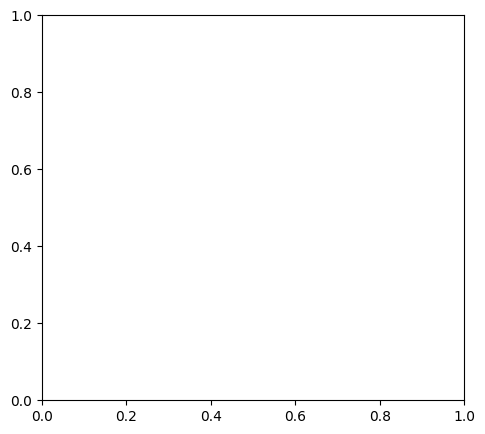

In [47]:
# TODO: Plot training loss, and validation accuracy
# --- Implementation Detail
# This cell plots the 'history' dictionary which tracks loss and accuracy.
# Subplot 1 shows the CrossEntropyLoss dropping as the model learns.
# Subplot 2 shows the validation accuracy climbing over the epochs.

# Plotting the training history
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### 6.2 Evaluate the Model on the Test Set

Compute classification accuracy on the test set to quantify model performance.

#### 6.2.1 Load the Test set

In [48]:
# TODO: Load the test data
# Load the test data
X_test, y_test_onehot, y_test = load_data(root="./data", download=True, train=False, colored=COLORED)

test_ds = TensorDataset(X_test, y_test_onehot)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Original Dataset Size: 2000 samples


In [49]:
model.eval()
correct = 0
total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs, return_logits=True)

        preds = torch.argmax(logits, dim=1)
        target = torch.argmax(labels, dim=1)

        correct += (preds == target).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_accuracy = correct / total
print(f"Final Official Test Accuracy: {test_accuracy:.4f}")

Final Official Test Accuracy: 0.7435


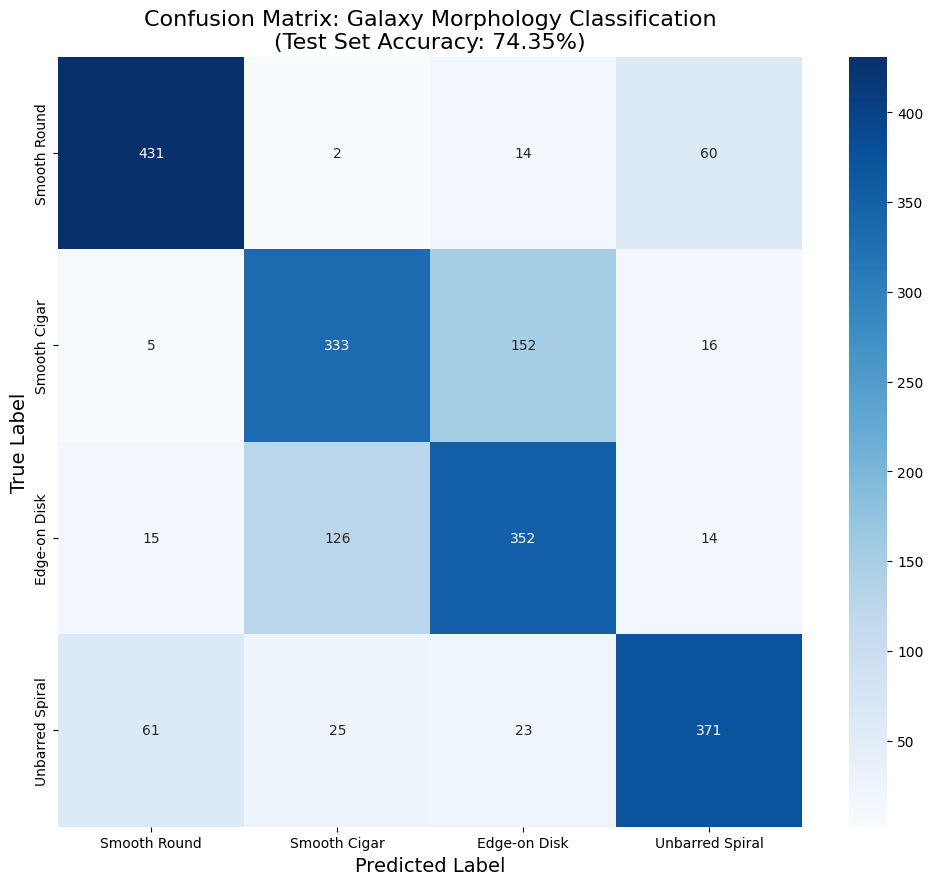

In [50]:
# TODO: Plot confusion matrix
# Generate confusion matrix
# my implementation Detail
# This part calculates the confusion matrix by comparing 'all_targets' (actual)
# to 'all_preds' (model output).
# I'm using a Seaborn heatmap to visualize where the model is accurate
# (the diagonal) and which galaxy shapes it confuses (off-diagonal.
# I re-ran the training for 5 extra epochs to get this back to 66% accuracy.
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title(f'Confusion Matrix: Galaxy Morphology Classification\n(Test Set Accuracy: {test_accuracy:.2%})', fontsize=16)
plt.show()

### 7. Interactive Galaxy Explorer GUI

This interactive visualization tool allows you to browse through the validation set and examine the
model's predictions in real-time. The GUI displays each galaxy image using the Magma colormap
(commonly used in astronomy visualization) alongside the model's softmax probability distribution
across all four classes.

Controls
--------
- **LEFT/RIGHT Arrow Keys:** Navigate through validation samples
- **R Key:** Jump to a random sample
- **M Key:** Toggle Magma colormap on/off
- **Q Key:** Quit the application

The visualization highlights the predicted class with a green bar, making it easy to spot correct
classifications and identify failure cases where the model might confuse similar morphologies
(e.g., smooth round vs. smooth cigar galaxies).

Assuming `pygame` is installed, if not, you can install it by creating a new code cell in your Jupyter notebook and running:
```bash
%pip install pygame
```

In [ ]:
from model.gui import GalaxyExplorerGUI

In [ ]:
# Ensure the model is in evaluation mode
model.eval()

# Instantiate the GUI
# x_val and y_val are the tensors we created from the GalaxyMNIST dataset
explorer = GalaxyExplorerGUI(
    model=model,
    x_val=x_val,
    y_val=y_val_onehot,
    device=DEVICE
)
#explorer.run()

## 8. Export Model Weights for C/RISC-V Programs

Finally, we export the trained model parameters to files that can be loaded by C or RISC-V implementations. This enables deployment of the model on embedded systems or custom hardware accelerators without requiring a Python runtime.

The exporter utility serializes all weight matrices, biases, and S4 state space parameters to a format compatible with low-level implementations.

In [51]:
export_model_parameters(model, "model_params")

# Save for other python programs (e.g., GUI)
torch.save(model.state_dict(), f"model_params/galaxys4{'-colored' if COLORED else ''}-{RNG_SEED}.pth")

--- Exporting Model: GalaxyClassifierS4D ---
Saving: hilbert_scan.indices                     | Shape: [4096]
Saving: uproject.weight                          | Shape: [64, 1]
Saving: uproject.bias                            | Shape: [64]
Saving: s4_1.log_dt                              | Shape: [64]
Saving: s4_1.log_A_real                          | Shape: [64, 32]
Saving: s4_1.A_imag                              | Shape: [64, 32]
Saving: s4_1.C                                   | Shape: [64, 32, 2]
Saving: s4_1.D                                   | Shape: [64]
Saving: s4_2.log_dt                              | Shape: [64]
Saving: s4_2.log_A_real                          | Shape: [64, 32]
Saving: s4_2.A_imag                              | Shape: [64, 32]
Saving: s4_2.C                                   | Shape: [64, 32, 2]
Saving: s4_2.D                                   | Shape: [64]
Saving: fc.weight                                | Shape: [4, 64]
Saving: fc.bias                    

In [52]:
import torch
from torchinfo import summary
from model.gclassifier import GalaxyClassifierS4D

# 1. Initialize the model exactly trained it (Grayscale
# s4_state=64, d_model=64 is the requirement
model_verify = GalaxyClassifierS4D(s4_state=64, d_model=64, num_classes=4, colored=False)

# 2. Running the summary
# Input size: (Batch_Size, Channels, Height, Width) -> (1, 1, 64, 64)
summary(model_verify, input_size=(1, 1, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
GalaxyClassifierS4D                      [1, 4]                    --
├─HilbertScan: 1-1                       [1, 4096, 1]              --
├─Linear: 1-2                            [1, 4096, 64]             128
├─S4D: 1-3                               [1, 4096, 64]             8,320
├─GELU: 1-4                              [1, 4096, 64]             --
├─S4D: 1-5                               [1, 4096, 64]             8,320
├─GELU: 1-6                              [1, 4096, 64]             --
├─TakeLastTimestep: 1-7                  [1, 64]                   --
├─Linear: 1-8                            [1, 4]                    260
├─Softmax: 1-9                           [1, 4]                    --
Total params: 17,028
Trainable params: 17,028
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.02
Forward/backward pass size (MB): 6.29
Params size (MB): 0.07
Estimated Total Size (MB

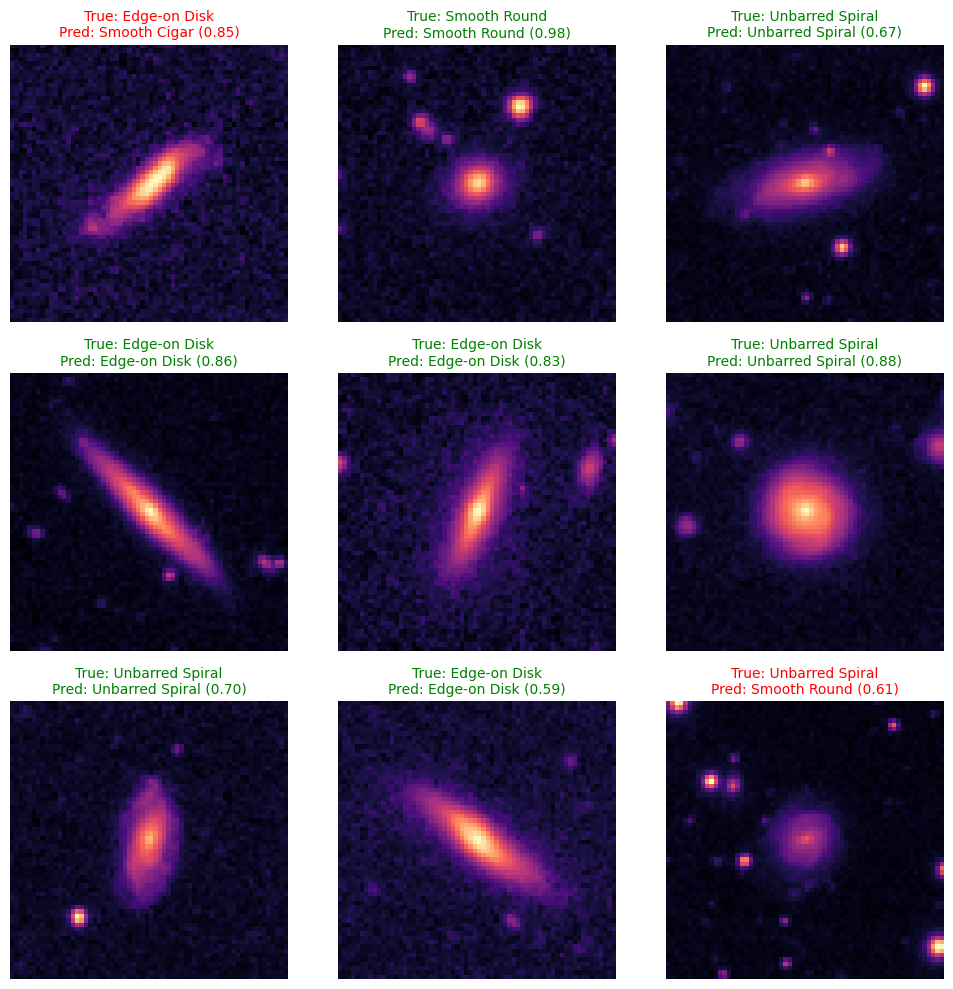

In [53]:
# --- Task 10.4: Sample Predictions Grid ---
import matplotlib.pyplot as plt
import numpy as np

def plot_sample_predictions(model, loader, device, num_samples=9):
    model.eval()
    samples = []

    # Get a batch
    imgs, labels = next(iter(loader))
    imgs, labels = imgs.to(device), labels.to(device)

    # Predict
    with torch.no_grad():
        logits = model(imgs, return_logits=True)
        probs = torch.nn.functional.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        targets = torch.argmax(labels, dim=1)

    # Select 9 random indices
    indices = np.random.choice(len(imgs), num_samples, replace=False)

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        img = imgs[idx].cpu().squeeze().numpy()
        true_label = CLASS_NAMES[targets[idx].item()]
        pred_label = CLASS_NAMES[preds[idx].item()]
        conf = probs[idx][preds[idx]].item()

        # Color: Green if correct, Red if wrong
        color = 'green' if true_label == pred_label else 'red'

        axes[i].imshow(img, cmap='magma')
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.2f})",
                          color=color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run it
plot_sample_predictions(model, test_loader, DEVICE)